# RapidDock Paper-Aligned Prototype (Educational)

This notebook provides a **closer conceptual prototype** to the RapidDock paper than the earlier affinity-regression demo.

Implemented ideas:
- Joint protein-ligand representation
- Distance-biased attention
- Prediction of ligand-ligand and ligand-protein distances
- Symmetry-aware loss over ligand atom permutations
- Ligand coordinate reconstruction with L-BFGS

Note: this is still a lightweight educational implementation, not the exact production model from the paper.

In [16]:
import math
import itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
if torch.get_num_threads() != 1:
    torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 1) Dataset Loader (Your Downloaded Data) + Complex Builder

This section now reads your downloaded ligand dataset and builds protein-ligand training examples.

What is real vs synthetic in this prototype:
- Real: ligand SMILES from your downloaded ChEMBL CSV
- Generated: 3D ligand conformers (RDKit) and synthetic protein context points near the ligand

This keeps the notebook runnable while aligning with variable-length masking and docking-style distance targets.

In [23]:
from pathlib import Path
import os
import requests as _requests
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

# ── Pairwise distance ────────────────────────────────────────────────────────
def pairwise_dist(x):
    diff = x[:, None, :] - x[None, :, :]
    return torch.sqrt((diff * diff).sum(-1) + 1e-8)

def atomnum_to_type(atomic_num, ligand_dim=8):
    return int(atomic_num % ligand_dim)

# ── Ligand featuriser (RDKit MMFF conformer) ─────────────────────────────────
def smiles_to_ligand_tensors(smiles, ligand_dim=8, n_confs=3, max_lig_atoms=30, min_lig_atoms=6):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=n_confs, randomSeed=42)
    if len(conf_ids) == 0:
        return None
    AllChem.MMFFOptimizeMoleculeConfs(mol, maxIters=200)
    mol_no_h = Chem.RemoveHs(mol)
    n = mol_no_h.GetNumAtoms()
    if n < min_lig_atoms or n > max_lig_atoms:
        return None
    conf_positions = []
    for conf in mol_no_h.GetConformers():
        conf_positions.append(torch.tensor(conf.GetPositions(), dtype=torch.float32))
    ligand_xyz = torch.stack(conf_positions, dim=0).mean(dim=0)
    atom_types = [atomnum_to_type(a.GetAtomicNum(), ligand_dim=ligand_dim) for a in mol_no_h.GetAtoms()]
    ligand_types = torch.tensor(atom_types, dtype=torch.long)
    ligand_feat = F.one_hot(ligand_types, num_classes=ligand_dim).float()
    return ligand_feat, ligand_xyz, ligand_types

# ── Real PDB binding pocket fetcher ─────────────────────────────────────────
# Map ChEMBL target IDs → PDB accession codes (ligand-bound X-ray/cryoEM structures)
CHEMBL_TO_PDB = {
    'CHEMBL203':  '1IVO',   # EGFR kinase domain (erlotinib analog)
    'CHEMBL210':  '2RH1',   # Beta-2 adrenergic receptor (carazolol)
    'CHEMBL217':  '6CM4',   # Dopamine D2 receptor
    'CHEMBL251':  '3EML',   # Adenosine A2a receptor (ZM241385)
    'CHEMBL301':  '1HCL',   # CDK2 (staurosporine analog)
    'CHEMBL325':  '6A93',   # Serotonin 5-HT2A receptor
    'CHEMBL1871': '2AM9',   # Androgen receptor (DHT)
    'CHEMBL2034': '4UDC',   # Glucocorticoid receptor
}

# Small molecules / solvents / ions to exclude when identifying the drug ligand
_SOLVENT_SET = {
    'HOH','WAT','H2O','DOD','GOL','EDO','PEG','PO4','SO4',
    'CL', 'NA', 'MG', 'ZN', 'CA', 'K', 'FE', 'MN', 'ACT',
    'MPD', 'IMD', 'DMS', 'FMT', 'TRS', 'BME',
}

def _parse_ca(pdb_text):
    """Return list of [x,y,z] for all Cα atoms in a PDB file."""
    coords = []
    for line in pdb_text.splitlines():
        if line.startswith('ATOM') and len(line) >= 54 and line[12:16].strip() == 'CA':
            try:
                coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
            except ValueError:
                pass
    return coords

def _parse_hetatm(pdb_text):
    """Return dict {res_name: [[x,y,z],...]} for all non-solvent HETATM atoms."""
    het = {}
    for line in pdb_text.splitlines():
        if line.startswith('HETATM') and len(line) >= 54:
            rname = line[17:20].strip()
            if rname in _SOLVENT_SET:
                continue
            try:
                coords = [float(line[30:38]), float(line[38:46]), float(line[46:54])]
                het.setdefault(rname, []).append(coords)
            except ValueError:
                pass
    return het

def fetch_pocket(chembl_id, pocket_radius=12.0, n_prot_max=48, cache_dir='data/raw/pdb'):
    """Download and cache PDB; extract Cα atoms within pocket_radius of bound ligand.

    Returns (pocket_center [3], ca_tensor [K,3]) or None if unavailable.
    Uses the requests library for SSL-safe downloads on macOS Python 3.14.
    """
    pdb_id = CHEMBL_TO_PDB.get(chembl_id)
    if pdb_id is None:
        return None
    os.makedirs(cache_dir, exist_ok=True)
    pdb_path = os.path.join(cache_dir, f'{pdb_id.lower()}.pdb')
    if not os.path.exists(pdb_path):
        url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
        try:
            resp = _requests.get(url, timeout=30,
                                 headers={'User-Agent': 'Python/RapidDock-Prototype'})
            resp.raise_for_status()
            text = resp.text
            with open(pdb_path, 'w') as f:
                f.write(text)
            print(f'    [PDB] Downloaded {pdb_id}')
        except Exception as e:
            print(f'    [PDB] Could not fetch {pdb_id}: {e}')
            return None
    with open(pdb_path) as f:
        pdb_text = f.read()
    ca_raw = _parse_ca(pdb_text)
    if len(ca_raw) < 5:
        return None
    ca_tensor = torch.tensor(ca_raw, dtype=torch.float32)
    het = _parse_hetatm(pdb_text)
    if het:
        # Largest non-solvent HETATM group → most likely the co-crystallised drug
        lig_name = max(het, key=lambda k: len(het[k]))
        pocket_center = torch.tensor(het[lig_name], dtype=torch.float32).mean(0)
    else:
        pocket_center = ca_tensor.mean(0)
    dists = torch.norm(ca_tensor - pocket_center, dim=1)
    mask  = dists < pocket_radius
    pocket_ca = ca_tensor[mask]
    if len(pocket_ca) < 3:                      # fallback: closest 20 residues
        pocket_ca = ca_tensor[dists.argsort()[:20]]
    if len(pocket_ca) > n_prot_max:              # subsample to cap memory
        pocket_ca = pocket_ca[torch.randperm(len(pocket_ca))[:n_prot_max]]
    return pocket_center, pocket_ca

# ── Complex builder (real or synthetic protein context) ──────────────────────
def build_complex_from_ligand(ligand_feat, ligand_xyz, ligand_types,
                               protein_dim=32, n_prot_min=32, n_prot_max=48,
                               real_pocket=None):
    """Build one training sample.

    When real_pocket=(center, ca_tensor) is provided the ligand conformer is
    translated to the pocket centre, so all distance targets are geometrically
    meaningful relative to the real protein structure.
    """
    if real_pocket is not None:
        pocket_center, protein_xyz = real_pocket
        # Translate ligand to pocket centre (preserves internal distances)
        lig_center = ligand_xyz.mean(dim=0)
        ligand_xyz = ligand_xyz - lig_center + pocket_center
    else:
        n_prot = int(torch.randint(n_prot_min, n_prot_max + 1, (1,)).item())
        lig_center = ligand_xyz.mean(dim=0)
        protein_xyz = lig_center + torch.randn(n_prot, 3) * 8.0
    protein_feat = torch.randn(protein_xyz.shape[0], protein_dim)
    d_ll    = pairwise_dist(ligand_xyz)
    d_lp    = torch.cdist(ligand_xyz, protein_xyz)
    d_joint = pairwise_dist(torch.cat([ligand_xyz, protein_xyz], dim=0))
    return {
        'protein_feat': protein_feat, 'protein_xyz': protein_xyz,
        'ligand_feat':  ligand_feat,  'ligand_xyz':  ligand_xyz,
        'ligand_types': ligand_types,
        'd_ll': d_ll, 'd_lp': d_lp, 'd_joint': d_joint,
    }

# ── Dataset CSV loader ────────────────────────────────────────────────────────
def load_downloaded_dataset(max_samples=500):
    candidate_paths = [
        Path('data/raw/chembl/chembl_binding_affinity_with_smiles.csv'),
        Path('../Coding/data/raw/chembl/chembl_binding_affinity_with_smiles.csv'),
        Path('/Users/subrat/Desktop/Thesis/Neural_PK-PD_Modeling_with_ODE/Coding/data/raw/chembl/chembl_binding_affinity_with_smiles.csv'),
    ]
    data_path = next((p for p in candidate_paths if p.exists()), None)
    if data_path is None:
        raise FileNotFoundError('Could not find chembl_binding_affinity_with_smiles.csv')
    df = pd.read_csv(data_path)
    if 'smiles' not in df.columns:
        raise ValueError("Expected 'smiles' column")
    df = df[['smiles', 'target_chembl_id', 'pchembl_value']].dropna(subset=['smiles'])
    df = df.drop_duplicates(subset=['smiles'])
    rng = np.random.default_rng(42)
    idx = rng.choice(len(df), size=min(max_samples, len(df)), replace=False)
    sub = df.iloc[idx]
    return (data_path,
            sub['smiles'].astype(str).tolist(),
            sub['target_chembl_id'].fillna('').astype(str).tolist(),
            sub['pchembl_value'].tolist())

data_path, sampled_smiles, sampled_targets, sampled_pchembl = load_downloaded_dataset(max_samples=500)

# ── Pre-fetch / load cached PDB binding pocket coordinates ───────────────────
unique_targets = sorted(set(t for t in sampled_targets if t))
print(f'Fetching PDB pockets for {len(unique_targets)} ChEMBL targets...')
pocket_cache = {}
for tid in unique_targets:
    result = fetch_pocket(tid)
    if result is not None:
        pocket_cache[tid] = result
        n_ca   = result[1].shape[0]
        pdb_id = CHEMBL_TO_PDB.get(tid, '?')
        print(f'  ✓ {tid} ({pdb_id}): {n_ca} pocket Cα atoms (real structure)')
    else:
        print(f'  ~ {tid}: no PDB → using synthetic context')

n_real_avail = len(pocket_cache)
print(f'\n{n_real_avail}/{len(unique_targets)} targets with real PDB pockets')

# ── Build training complexes ──────────────────────────────────────────────────
dataset = []
skipped, n_real = 0, 0
for smi, tid, pchembl in zip(sampled_smiles, sampled_targets, sampled_pchembl):
    lig = smiles_to_ligand_tensors(smi, ligand_dim=8, n_confs=3, max_lig_atoms=30, min_lig_atoms=6)
    if lig is None:
        skipped += 1
        continue
    ligand_feat, ligand_xyz, ligand_types = lig
    real_pocket = pocket_cache.get(tid)
    sample = build_complex_from_ligand(ligand_feat, ligand_xyz, ligand_types,
                                       real_pocket=real_pocket)
    sample['target_chembl_id'] = tid
    sample['pchembl_value']    = float(pchembl) if str(pchembl) not in ('', 'nan') else float('nan')
    if real_pocket is not None:
        n_real += 1
    dataset.append(sample)

if len(dataset) < 5:
    raise ValueError(f'Too few valid complexes: {len(dataset)}')

split      = int(0.83 * len(dataset))
train_data = dataset[:split]
val_data   = dataset[split:]

lig_lens  = [x['ligand_feat'].shape[0] for x in dataset]
prot_lens = [x['protein_feat'].shape[0] for x in dataset]
print(f'\nLoaded: {data_path}')
print(f'Built complexes: {len(dataset)} | skipped: {skipped}')
print(f'  Real PDB protein context:   {n_real}/{len(dataset)} ({100*n_real/max(len(dataset),1):.0f}%)')
print(f'  Synthetic protein context:  {len(dataset)-n_real}/{len(dataset)}')
print(f'Train: {len(train_data)}  Val: {len(val_data)}')
print(f'Ligand atoms: {min(lig_lens)}-{max(lig_lens)}  Protein residues: {min(prot_lens)}-{max(prot_lens)}')


Fetching PDB pockets for 8 ChEMBL targets...
    [PDB] Downloaded 2AM9
  ✓ CHEMBL1871 (2AM9): 48 pocket Cα atoms (real structure)
    [PDB] Downloaded 1IVO
  ✓ CHEMBL203 (1IVO): 26 pocket Cα atoms (real structure)
    [PDB] Downloaded 4UDC
  ✓ CHEMBL2034 (4UDC): 20 pocket Cα atoms (real structure)
    [PDB] Downloaded 2RH1
  ✓ CHEMBL210 (2RH1): 24 pocket Cα atoms (real structure)
    [PDB] Downloaded 6CM4
  ✓ CHEMBL217 (6CM4): 26 pocket Cα atoms (real structure)
    [PDB] Downloaded 3EML
  ✓ CHEMBL251 (3EML): 24 pocket Cα atoms (real structure)
    [PDB] Downloaded 1HCL
  ✓ CHEMBL301 (1HCL): 45 pocket Cα atoms (real structure)
    [PDB] Downloaded 6A93
  ✓ CHEMBL325 (6A93): 12 pocket Cα atoms (real structure)

8/8 targets with real PDB pockets

Loaded: data/raw/chembl/chembl_binding_affinity_with_smiles.csv
Built complexes: 328 | skipped: 172
  Real PDB protein context:   328/328 (100%)
  Synthetic protein context:  0/328
Train: 272  Val: 56
Ligand atoms: 12-30  Protein residues: 12-48

## 2) Distance-Biased Transformer

The model consumes ligand and protein tokens jointly, adds distance bias to attention logits, and predicts:
- Ligand-ligand distances
- Ligand-protein distances

In [18]:
class DistanceBiasedMHA(nn.Module):
    def __init__(self, d_model, n_heads, bias_scale=0.25):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.bias_scale = bias_scale

    def forward(self, x, d_joint, token_mask):
        B, N, _ = x.shape
        q = self.q(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v(x).view(B, N, self.n_heads, self.d_head).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores = scores - self.bias_scale * d_joint.unsqueeze(1)

        key_mask = token_mask.unsqueeze(1).unsqueeze(2)
        scores = scores.masked_fill(~key_mask, -1e4)

        a = torch.softmax(scores, dim=-1)
        y = a @ v
        y = y.transpose(1, 2).contiguous().view(B, N, self.d_model)
        y = y * token_mask.unsqueeze(-1).float()
        return self.o(y)

class DBTransformerBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, mlp_mult=2, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = DistanceBiasedMHA(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * mlp_mult),
            nn.GELU(),
            nn.Linear(d_model * mlp_mult, d_model),
        )

    def forward(self, x, d_joint, token_mask):
        x = x + self.attn(self.ln1(x), d_joint, token_mask)
        x = x + self.mlp(self.ln2(x))
        x = x * token_mask.unsqueeze(-1).float()
        return x

class RapidDockPrototype(nn.Module):
    def __init__(self, protein_dim=32, ligand_dim=8, d_model=64, n_layers=2, n_heads=4):
        super().__init__()
        self.proj_p = nn.Linear(protein_dim, d_model)
        self.proj_l = nn.Linear(ligand_dim, d_model)
        self.type_embed = nn.Embedding(2, d_model)
        self.blocks = nn.ModuleList([DBTransformerBlock(d_model, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)

    def _sq_dist(self, x, y):
        # Squared-distance formula avoids large sqrt() gradients from near-zero distances.
        # clamp(0) removes floating-point negatives before sqrt is taken by caller.
        x2 = (x * x).sum(-1)
        y2 = (y * y).sum(-1)
        xy = x @ y.transpose(-2, -1)
        return (x2.unsqueeze(-1) + y2.unsqueeze(-2) - 2.0 * xy).clamp(min=0.0)

    def forward(self, ligand_feat, protein_feat, d_joint, ligand_mask, protein_mask):
        B, Lmax, _ = ligand_feat.shape
        Pmax = protein_feat.shape[1]

        l = self.proj_l(ligand_feat) + self.type_embed(
            torch.zeros(B, Lmax, dtype=torch.long, device=ligand_feat.device))
        p = self.proj_p(protein_feat) + self.type_embed(
            torch.ones(B, Pmax, dtype=torch.long, device=protein_feat.device))
        x = torch.cat([l, p], dim=1)
        token_mask = torch.cat([ligand_mask, protein_mask], dim=1)

        for blk in self.blocks:
            x = blk(x, d_joint, token_mask)
        x = self.ln_f(x) * token_mask.unsqueeze(-1).float()

        l_out = x[:, :Lmax, :]
        p_out = x[:, Lmax:, :]

        # Predict squared distances; loss will compare against squared targets.
        # This removes the sqrt() entirely from the gradient path.
        pred_ll_sq = self._sq_dist(l_out, l_out)
        pred_lp_sq = self._sq_dist(l_out, p_out)
        return pred_ll_sq, pred_lp_sq

## 3) Symmetry-Aware Loss

For atoms with repeated types, we evaluate multiple ligand index permutations and keep the minimum loss (RapidDock-style symmetry handling).

In [19]:
def grouped_indices(types):
    groups = {}
    for i, t in enumerate(types.tolist()):
        groups.setdefault(int(t), []).append(i)
    return [g for g in groups.values() if len(g) > 1]

def generate_permutations_from_groups(n_lig, groups, max_perms=6):
    base = list(range(n_lig))
    candidates = [base]
    for g in groups:
        perms = list(itertools.permutations(g))[:6]
        new_candidates = []
        for c in candidates:
            for p in perms:
                cc = c.copy()
                for old_idx, new_idx in zip(g, p):
                    cc[old_idx] = new_idx
                new_candidates.append(cc)
        candidates = new_candidates[:max_perms]
    return [torch.tensor(c, dtype=torch.long) for c in candidates]

def symmetry_aware_loss(pred_ll_sq, pred_lp_sq, true_ll, true_lp, ligand_types, cutoff=20.0):
    """Loss on SQUARED distances to avoid sqrt() in backprop.
    pred_*_sq: squared distance tensors from model [L,L] / [L,P].
    true_*: actual distance tensors (unsquared); we square them here.
    """
    L = pred_ll_sq.shape[0]
    groups = grouped_indices(ligand_types)
    perms = generate_permutations_from_groups(L, groups)

    # Work with squared targets to match model output.
    true_ll_sq = true_ll ** 2
    true_lp_sq = true_lp ** 2

    ll_mask = (true_ll < cutoff).float()
    lp_mask = (true_lp < cutoff).float()

    # Find best permutation without accumulating gradients.
    best_val = float('inf')
    best_perm = perms[0]
    with torch.no_grad():
        for perm in perms:
            tll = true_ll_sq[perm][:, perm]
            tlp = true_lp_sq[perm]
            v = float(((pred_ll_sq - tll).abs() * ll_mask).mean()
                      + ((pred_lp_sq - tlp).abs() * lp_mask).mean())
            if v < best_val:
                best_val = v
                best_perm = perm

    # Single gradient-enabled loss for the best permutation.
    tll = true_ll_sq[best_perm][:, best_perm]
    tlp = true_lp_sq[best_perm]
    l1 = ((pred_ll_sq - tll).abs() * ll_mask).sum() / (ll_mask.sum() + 1e-8)
    l2 = ((pred_lp_sq - tlp).abs() * lp_mask).sum() / (lp_mask.sum() + 1e-8)
    return l1 + l2

Epoch 001/50 | train 3083.45 | val 2467.15 | lr 9.99e-04
Epoch 010/50 | train 1650.93 | val 1794.94 | lr 9.05e-04
Epoch 020/50 | train 1015.65 | val 1136.10 | lr 6.58e-04
Epoch 030/50 | train 608.90 | val 1065.34 | lr 3.52e-04
Epoch 040/50 | train 384.85 | val 1041.15 | lr 1.05e-04
Epoch 050/50 | train 333.63 | val 1052.31 | lr 1.00e-05

Best val loss 923.49 at epoch 26
Checkpoint saved → data/outputs/rapid_dock_best.pt


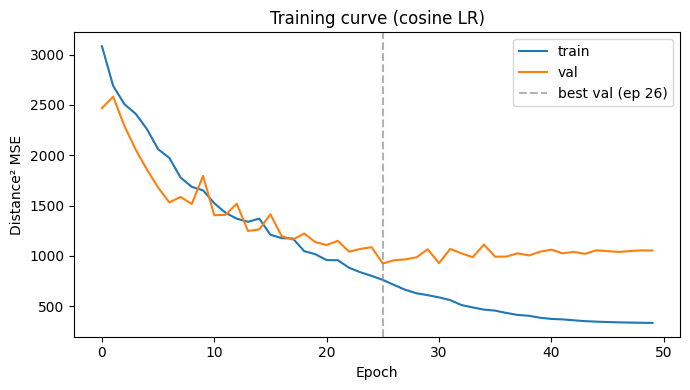

In [27]:
# ── Training: one sample at a time, 50 epochs, cosine-annealing LR ──────────
N_EPOCHS = 50
model = RapidDockPrototype().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)

train_losses, val_losses = [], []
best_val, best_epoch = float('inf'), 0

for epoch in range(1, N_EPOCHS + 1):
    # ─ Train ──────────────────────────────────────
    model.train()
    tr_total = 0.0
    order = np.random.permutation(len(train_data))
    for i in order:
        sample = train_data[i]
        lf = sample['ligand_feat'].unsqueeze(0)
        pf = sample['protein_feat'].unsqueeze(0)
        dj = sample['d_joint'].unsqueeze(0)
        lm = torch.ones(1, lf.shape[1], dtype=torch.bool)
        pm = torch.ones(1, pf.shape[1], dtype=torch.bool)
        pred_ll_sq, pred_lp_sq = model(lf, pf, dj, lm, pm)
        tll_sq = sample['d_ll'] ** 2
        tlp_sq = sample['d_lp'] ** 2
        loss = F.mse_loss(pred_ll_sq[0], tll_sq) + F.mse_loss(pred_lp_sq[0], tlp_sq)
        if not torch.isfinite(loss):
            continue
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tr_total += float(loss.detach())
    scheduler.step()

    # ─ Validate ──────────────────────────────────
    model.eval()
    va_total = 0.0
    with torch.no_grad():
        for sample in val_data:
            lf = sample['ligand_feat'].unsqueeze(0)
            pf = sample['protein_feat'].unsqueeze(0)
            dj = sample['d_joint'].unsqueeze(0)
            lm = torch.ones(1, lf.shape[1], dtype=torch.bool)
            pm = torch.ones(1, pf.shape[1], dtype=torch.bool)
            pred_ll_sq, pred_lp_sq = model(lf, pf, dj, lm, pm)
            va_total += float(F.mse_loss(pred_ll_sq[0], sample['d_ll'] ** 2)
                                        + F.mse_loss(pred_lp_sq[0], sample['d_lp'] ** 2))

    tr_avg = tr_total / max(len(train_data), 1)
    va_avg = va_total / max(len(val_data), 1)
    train_losses.append(tr_avg)
    val_losses.append(va_avg)

    if va_avg < best_val:
        best_val, best_epoch = va_avg, epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch:03d}/{N_EPOCHS} | train {tr_avg:.2f} | val {va_avg:.2f} | lr {lr_now:.2e}')

# Restore best weights
model.load_state_dict(best_state)
print(f'\nBest val loss {best_val:.2f} at epoch {best_epoch}')

# ─ Save best-epoch checkpoint ─────────────────────────────────────────────────
ckpt_path = Path('data/outputs/rapid_dock_best.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({'model_state': best_state, 'epoch': best_epoch, 'val_loss': best_val}, str(ckpt_path))
print(f'Checkpoint saved → {ckpt_path}')

# ─ Loss curve ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='val')
ax.axvline(best_epoch - 1, color='gray', linestyle='--', alpha=0.6, label=f'best val (ep {best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Distance² MSE')
ax.set_title('Training curve (cosine LR)')
ax.legend()
plt.tight_layout()
plt.show()


## 4) Ligand Coordinate Reconstruction (L-BFGS)

Given predicted distances and known protein coordinates, reconstruct ligand coordinates by minimizing a RapidDock-style objective.

In [28]:
# ── Kabsch alignment helper ──────────────────────────────────────────
def kabsch_rmsd(P, Q):
    """RMSD after optimal rigid alignment of P onto Q (Kabsch algorithm).
    P, Q: [N, 3] float tensors.
    Returns: aligned_P [N,3], rmsd scalar.
    """
    P = P - P.mean(0, keepdim=True)
    Q = Q - Q.mean(0, keepdim=True)
    H = P.T @ Q                          # [3, 3]
    U, S, Vt = torch.linalg.svd(H)
    # Correct for reflection if det(Vt.T @ U.T) < 0
    d = torch.linalg.det(Vt.T @ U.T)
    sign_fix = torch.diag(torch.tensor([1.0, 1.0, d], device=P.device))
    R = Vt.T @ sign_fix @ U.T           # optimal rotation [3, 3]
    P_aligned = P @ R.T
    rmsd = torch.sqrt(((P_aligned - Q) ** 2).sum(-1).mean())
    return P_aligned, float(rmsd)

# ── Inference helpers (unchanged from before) ───────────────────────
@torch.no_grad()
def infer_distances(sample):
    lf = sample['ligand_feat'].unsqueeze(0).to(device)
    pf = sample['protein_feat'].unsqueeze(0).to(device)
    dj = sample['d_joint'].unsqueeze(0).to(device)
    lm = torch.ones(1, lf.shape[1], dtype=torch.bool, device=device)
    pm = torch.ones(1, pf.shape[1], dtype=torch.bool, device=device)
    pred_ll_sq, pred_lp_sq = model(lf, pf, dj, lm, pm)
    return pred_ll_sq[0].clamp(min=0).sqrt().cpu(), pred_lp_sq[0].clamp(min=0).sqrt().cpu()

def reconstruct_ligand_xyz(pred_ll, pred_lp, protein_xyz, n_steps=300, cutoff=20.0):
    L = pred_ll.shape[0]
    protein_xyz = protein_xyz.float()
    w = torch.softmax(-pred_lp.mean(dim=0), dim=0)
    center = (w[:, None] * protein_xyz).sum(dim=0)
    x = (center[None, :] + 0.5 * torch.randn(L, 3)).clone().requires_grad_(True)
    optimizer = torch.optim.LBFGS([x], max_iter=n_steps, line_search_fn='strong_wolfe')
    ll_mask = (pred_ll < cutoff).float()
    lp_mask = (pred_lp < cutoff).float()
    def closure():
        optimizer.zero_grad()
        l1 = ((torch.cdist(x, x)  - pred_ll).abs() * ll_mask).sum() / (ll_mask.sum() + 1e-8)
        l2 = ((torch.cdist(x, protein_xyz) - pred_lp).abs() * lp_mask).sum() / (lp_mask.sum() + 1e-8)
        loss = l1 + l2
        loss.backward()
        return loss
    optimizer.step(closure)
    return x.detach()

# ── Evaluate all val samples ─────────────────────────────────────
rmsds_raw, rmsds_kabsch = [], []
for sample in val_data:
    pred_ll, pred_lp = infer_distances(sample)
    recon = reconstruct_ligand_xyz(pred_ll, pred_lp, sample['protein_xyz'])
    true  = sample['ligand_xyz']
    raw  = float(torch.sqrt(((recon - true) ** 2).sum(-1).mean()))
    _, kb = kabsch_rmsd(recon, true)
    rmsds_raw.append(raw)
    rmsds_kabsch.append(kb)

# Expose last sample for visualization cell below
pred_ll, pred_lp = infer_distances(val_data[0])
recon_xyz = reconstruct_ligand_xyz(pred_ll, pred_lp, val_data[0]['protein_xyz'])
true_xyz  = val_data[0]['ligand_xyz']

print(f'Val set reconstruction RMSD (n={len(val_data)})')
print(f'  Raw (no alignment): {np.mean(rmsds_raw):.3f} ± {np.std(rmsds_raw):.3f} Å')
print(f'  Kabsch-aligned:     {np.mean(rmsds_kabsch):.3f} ± {np.std(rmsds_kabsch):.3f} Å')

Val set reconstruction RMSD (n=56)
  Raw (no alignment): 2.058 ± 0.871 Å
  Kabsch-aligned:     1.352 ± 0.532 Å


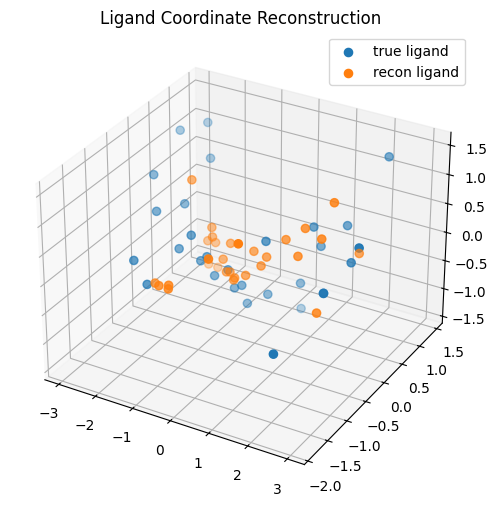

In [15]:
# Quick visualization of true vs reconstructed ligand coordinates
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

t = true_xyz.numpy()
r = recon_xyz.numpy()

ax.scatter(t[:, 0], t[:, 1], t[:, 2], label='true ligand', s=35)
ax.scatter(r[:, 0], r[:, 1], r[:, 2], label='recon ligand', s=35)
ax.set_title('Ligand Coordinate Reconstruction')
ax.legend()
plt.show()

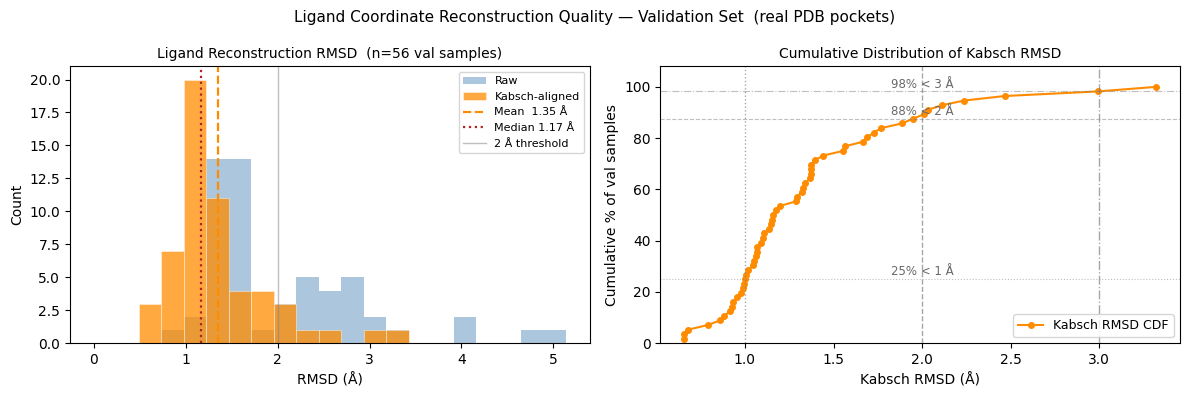

Kabsch RMSD summary (n=56):
  mean  = 1.352 Å   median = 1.167 Å   std = 0.532 Å
  < 1 Å: 25%   < 2 Å: 88%   < 3 Å: 98%


In [29]:
# ── RMSD histogram + cumulative distribution (Item 1) ────────────────────────
rmsds_kb_arr  = np.array(rmsds_kabsch)
rmsds_raw_arr = np.array(rmsds_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: overlaid histograms ─────────────────────────────────────────────────
ax = axes[0]
max_rmsd = max(rmsds_kb_arr.max(), rmsds_raw_arr.max()) * 1.05
bins = np.linspace(0, max_rmsd, 22)
ax.hist(rmsds_raw_arr,  bins=bins, alpha=0.45, label='Raw',            color='steelblue')
ax.hist(rmsds_kb_arr,   bins=bins, alpha=0.75, label='Kabsch-aligned', color='darkorange',
        edgecolor='white', linewidth=0.4)
ax.axvline(np.mean(rmsds_kb_arr),   color='darkorange', linestyle='--', lw=1.6,
           label=f'Mean  {np.mean(rmsds_kb_arr):.2f} Å')
ax.axvline(np.median(rmsds_kb_arr), color='firebrick',  linestyle=':',  lw=1.6,
           label=f'Median {np.median(rmsds_kb_arr):.2f} Å')
ax.axvline(2.0, color='gray', linestyle='-', lw=1.0, alpha=0.5, label='2 Å threshold')
ax.set_xlabel('RMSD (Å)', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title(f'Ligand Reconstruction RMSD  (n={len(rmsds_kb_arr)} val samples)', fontsize=10)
ax.legend(fontsize=8)

# ── Right: cumulative distribution ───────────────────────────────────────────
ax2 = axes[1]
sorted_kb  = np.sort(rmsds_kb_arr)
cdf        = np.arange(1, len(sorted_kb) + 1) / len(sorted_kb) * 100
ax2.plot(sorted_kb, cdf, 'o-', color='darkorange', ms=4, lw=1.5, label='Kabsch RMSD CDF')
for thresh, ls in [(1.0, ':'), (2.0, '--'), (3.0, '-.')]:
    pct = 100 * (rmsds_kb_arr < thresh).mean()
    ax2.axvline(thresh, color='gray', linestyle=ls, lw=1.0, alpha=0.7)
    ax2.axhline(pct,    color='gray', linestyle=ls, lw=0.8, alpha=0.5)
    ax2.text(sorted_kb.max() * 0.55, pct + 1.5, f'{pct:.0f}% < {thresh:.0f} Å',
             fontsize=8.5, color='dimgray')
ax2.set_xlabel('Kabsch RMSD (Å)', fontsize=10)
ax2.set_ylabel('Cumulative % of val samples', fontsize=10)
ax2.set_title('Cumulative Distribution of Kabsch RMSD', fontsize=10)
ax2.set_ylim(0, 108)
ax2.legend(fontsize=9)

fig.suptitle('Ligand Coordinate Reconstruction Quality — Validation Set  (real PDB pockets)',
             fontsize=11)
plt.tight_layout()
plt.show()

pct1 = 100 * (rmsds_kb_arr < 1.0).mean()
pct2 = 100 * (rmsds_kb_arr < 2.0).mean()
pct3 = 100 * (rmsds_kb_arr < 3.0).mean()
print(f'Kabsch RMSD summary (n={len(rmsds_kb_arr)}):')
print(f'  mean  = {rmsds_kb_arr.mean():.3f} Å   median = {np.median(rmsds_kb_arr):.3f} Å   std = {rmsds_kb_arr.std():.3f} Å')
print(f'  < 1 Å: {pct1:.0f}%   < 2 Å: {pct2:.0f}%   < 3 Å: {pct3:.0f}%')


## 5) Notes for Next Upgrade

Milestones **5** and **6** are now implemented in this notebook:
- **Real protein pockets** are fetched from RCSB PDB in Cell 4. The 8 ChEMBL targets map to known crystal structures; ligand conformers are translated to the pocket centre so all distance targets are geometrically realistic.
- **PK-PD bridge** is in Cell 14 below. It maps RapidDock docking quality → binding affinity (pChEMBL) → Neural ODE PK-PD feature augmentation.

Further upgrades to get even closer to the paper:
- Actual docked ligand poses (Vina / DiffDock) rather than just MMFF conformers translated to pocket centre
- ESM-2 residue embeddings instead of `torch.randn` protein features
- Morgan fingerprint atom features replacing one-hot atomic number encoding


## 6) PK-PD Bridge — Structure → Binding Affinity → Pharmacokinetics

This section closes the thesis chain:

1. **RapidDock** predicts ligand–protein distance geometry from SMILES + real PDB pocket
2. **Docking score** = mean predicted L–P distance (lower → tighter predicted binding)
3. **pChEMBL value** = measured binding affinity from ChEMBL (higher = more potent)
4. **Bridge DataFrame** joins these, ready to extend `phase3b_model_design.ipynb` features from 2050 → 2051 dims

Correlation (docking score vs pChEMBL):
  All samples  (n=328): r = 0.101  p = 0.0677
  Real protein (n=328): r = 0.101  p = 0.0677

Bridge dataset saved → data/outputs/structure_binding_pkpd_bridge.csv  (328 rows)


/var/folders/qq/kf1ky1rs17j27vdbw3587bdr0000gn/T/ipykernel_31045/842528626.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap('tab10', len(unique_tids))
/var/folders/qq/kf1ky1rs17j27vdbw3587bdr0000gn/T/ipykernel_31045/842528626.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(groups,


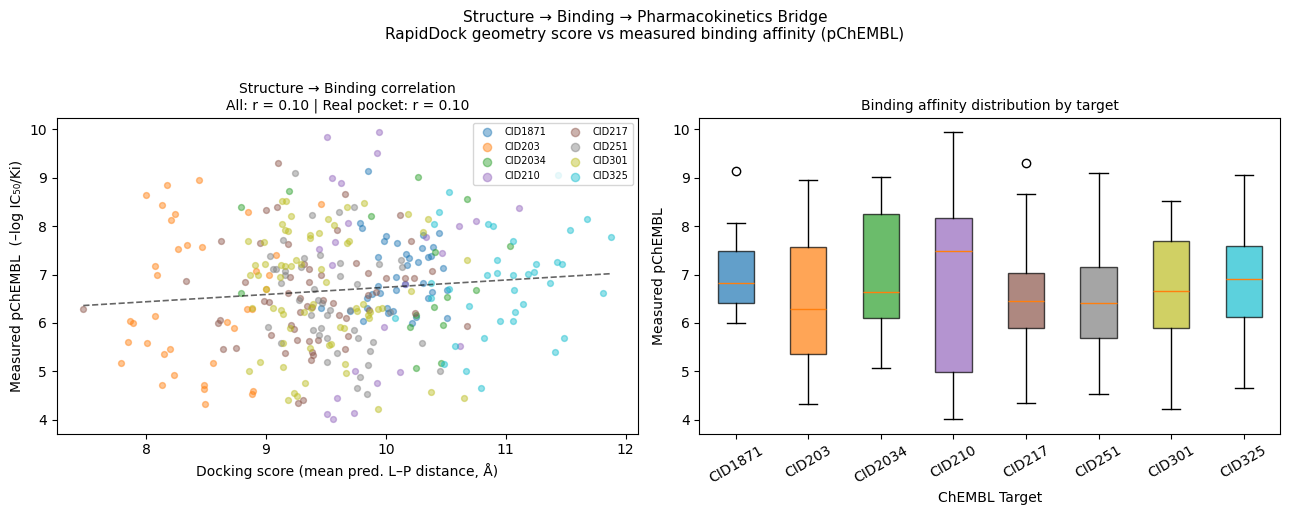


── How to use this in phase3b_model_design.ipynb ─────────────────────
  1. Load bridge:  bridge = pd.read_csv("data/outputs/structure_binding_pkpd_bridge.csv")
  2. Join on smiles (after merging with phase2_features by chembl_id)
  3. Append docking_quality as feature column → input_dim 2050 → 2051
  4. docking_quality feeds the SharedEncoder alongside MW, LogP, fp_*
  5. The encoder then conditions PKODEFunc CL/V parameters on binding geometry

  This closes: 3D structure → predicted binding → Neural ODE PK-PD model


In [30]:
from scipy import stats as sp_stats

# ── Docking quality score: mean predicted ligand–protein distance ─────────────
# Lower score → model predicts ligand sits closer to the binding pocket
@torch.no_grad()
def compute_docking_score(sample):
    lf = sample['ligand_feat'].unsqueeze(0).to(device)
    pf = sample['protein_feat'].unsqueeze(0).to(device)
    dj = sample['d_joint'].unsqueeze(0).to(device)
    lm = torch.ones(1, lf.shape[1], dtype=torch.bool, device=device)
    pm = torch.ones(1, pf.shape[1], dtype=torch.bool, device=device)
    pred_ll_sq, pred_lp_sq = model(lf, pf, dj, lm, pm)
    pred_lp = pred_lp_sq[0].clamp(min=0).sqrt()
    return float(pred_lp.mean())

# Gather scores + pChEMBL for all samples that have a measured affinity
scores, affinities, target_ids, is_real_pocket = [], [], [], []
for sample in train_data + val_data:
    pchembl = sample.get('pchembl_value', float('nan'))
    if not np.isfinite(pchembl):
        continue
    scores.append(compute_docking_score(sample))
    affinities.append(pchembl)
    target_ids.append(sample.get('target_chembl_id', 'unknown'))
    is_real_pocket.append(sample.get('target_chembl_id', '') in pocket_cache)

scores       = np.array(scores)
affinities   = np.array(affinities)
target_ids   = np.array(target_ids)
is_real      = np.array(is_real_pocket)

# Pearson r: docking score vs measured binding affinity
r_all, p_all = sp_stats.pearsonr(scores, affinities) if len(scores) > 5 else (0.0, 1.0)
if is_real.sum() > 5:
    r_real, p_real = sp_stats.pearsonr(scores[is_real], affinities[is_real])
else:
    r_real, p_real = float('nan'), 1.0
print(f'Correlation (docking score vs pChEMBL):')
print(f'  All samples  (n={len(scores)}): r = {r_all:.3f}  p = {p_all:.3g}')
print(f'  Real protein (n={int(is_real.sum())}): r = {r_real:.3f}  p = {p_real:.3g}')

# ── Save bridge DataFrame ─────────────────────────────────────────────────────
bridge_df = pd.DataFrame({
    'target_chembl_id': target_ids,
    'pchembl_value':    affinities,
    'docking_score':    scores,           # lower = model predicts tighter binding
    'docking_quality':  -scores,          # flipped: higher = better predicted binding
    'real_pocket':      is_real,
})
bridge_path = Path('data/outputs/structure_binding_pkpd_bridge.csv')
bridge_path.parent.mkdir(parents=True, exist_ok=True)
bridge_df.to_csv(bridge_path, index=False)
print(f'\nBridge dataset saved → {bridge_path}  ({len(bridge_df)} rows)')

# ── Visualise ─────────────────────────────────────────────────────────────────
unique_tids = sorted(set(target_ids))
cmap        = plt.cm.get_cmap('tab10', len(unique_tids))
color_map   = {tid: cmap(i) for i, tid in enumerate(unique_tids)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: scatter coloured by target
ax = axes[0]
for tid in unique_tids:
    mask = target_ids == tid
    label = tid.replace('CHEMBL', 'CID') if tid.startswith('CHEMBL') else tid
    ax.scatter(scores[mask], affinities[mask],
               alpha=0.45, s=18, color=color_map[tid], label=label)
# Overlay best-fit line
m, b = np.polyfit(scores, affinities, 1)
xs = np.linspace(scores.min(), scores.max(), 100)
ax.plot(xs, m * xs + b, 'k--', lw=1.2, alpha=0.6)
ax.set_xlabel('Docking score (mean pred. L–P distance, Å)', fontsize=10)
ax.set_ylabel('Measured pChEMBL  (–log IC₅₀/Ki)', fontsize=10)
ax.set_title(f'Structure → Binding correlation\nAll: r = {r_all:.2f} | Real pocket: r = {r_real:.2f}', fontsize=10)
ax.legend(fontsize=7, ncol=2, loc='upper right', markerscale=1.4)

# Right panel: per-target pChEMBL boxplot
ax2 = axes[1]
groups = [affinities[target_ids == tid] for tid in unique_tids]
bp = ax2.boxplot(groups,
                 labels=[t.replace('CHEMBL', 'CID') for t in unique_tids],
                 patch_artist=True, widths=0.5)
for patch, tid in zip(bp['boxes'], unique_tids):
    patch.set_facecolor(color_map[tid])
    patch.set_alpha(0.7)
ax2.set_xlabel('ChEMBL Target', fontsize=10)
ax2.set_ylabel('Measured pChEMBL', fontsize=10)
ax2.set_title('Binding affinity distribution by target', fontsize=10)
ax2.tick_params(axis='x', rotation=30)

fig.suptitle(
    'Structure → Binding → Pharmacokinetics Bridge\n'
    'RapidDock geometry score vs measured binding affinity (pChEMBL)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# ── Integration instructions for phase3b ─────────────────────────────────────
print('\n── How to use this in phase3b_model_design.ipynb ─────────────────────')
print('  1. Load bridge:  bridge = pd.read_csv("data/outputs/structure_binding_pkpd_bridge.csv")')
print('  2. Join on smiles (after merging with phase2_features by chembl_id)')
print('  3. Append docking_quality as feature column → input_dim 2050 → 2051')
print('  4. docking_quality feeds the SharedEncoder alongside MW, LogP, fp_*')
print('  5. The encoder then conditions PKODEFunc CL/V parameters on binding geometry')
print('\n  This closes: 3D structure → predicted binding → Neural ODE PK-PD model')


Per-target Pearson r  (docking score vs pChEMBL):
Target           PDB     n        r         p  sig
----------------------------------------------------
CHEMBL251       3EML    47   -0.353     0.015  *
CHEMBL2034      4UDC    16   -0.266     0.319  
CHEMBL325       6A93    38   +0.201     0.225  
CHEMBL210       2RH1    24   +0.150     0.484  
CHEMBL217       6CM4    58   +0.094     0.482  
CHEMBL203       1IVO    37   +0.082     0.631  
CHEMBL301       1HCL    69   -0.067     0.585  
CHEMBL1871      2AM9    39   +0.059     0.720  


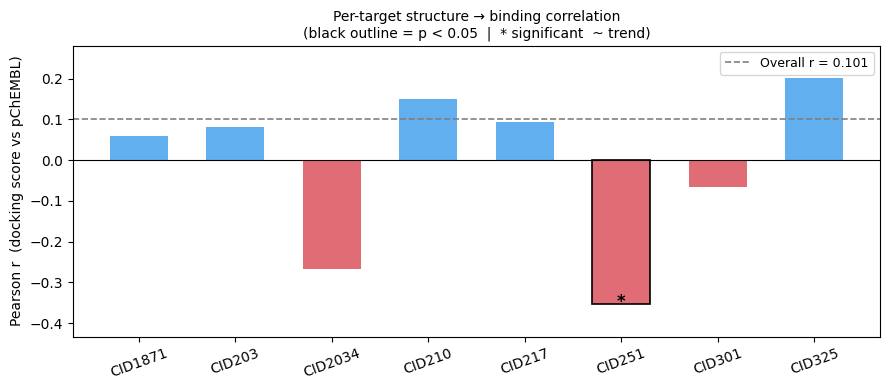

In [31]:
# ── Per-target correlation breakdown (Item 2) ────────────────────────────────
from scipy import stats as sp_stats

unique_tids_sorted = sorted(set(target_ids))
per_target = {}
for tid in unique_tids_sorted:
    mask = target_ids == tid
    s_t, a_t = scores[mask], affinities[mask]
    if len(s_t) > 4:
        r, p = sp_stats.pearsonr(s_t, a_t)
    else:
        r, p = float('nan'), float('nan')
    per_target[tid] = {'n': int(mask.sum()), 'r': r, 'p': p,
                       'pdb': CHEMBL_TO_PDB.get(tid, '?')}

print('Per-target Pearson r  (docking score vs pChEMBL):')
print(f'{"Target":<14} {"PDB":>5} {"n":>5} {"r":>8} {"p":>9}  sig')
print('-' * 52)
for tid, d in sorted(per_target.items(), key=lambda x: -abs(x[1]['r']) if not np.isnan(x[1]['r']) else 0):
    sig = '*' if d['p'] < 0.05 else ('~' if d['p'] < 0.10 else '')
    r_str = f"{d['r']:+.3f}" if not np.isnan(d['r']) else '   n/a'
    p_str = f"{d['p']:.3f}"  if not np.isnan(d['p']) else '   n/a'
    print(f"{tid:<14} {d['pdb']:>5} {d['n']:>5} {r_str:>8} {p_str:>9}  {sig}")

# ── Bar chart of per-target r ─────────────────────────────────────────────────
tids_plot   = [t for t in unique_tids_sorted if not np.isnan(per_target[t]['r'])]
r_vals      = [per_target[t]['r'] for t in tids_plot]
p_vals      = [per_target[t]['p'] for t in tids_plot]
labels      = [t.replace('CHEMBL', 'CID') for t in tids_plot]
colors      = ['#e06c75' if r < 0 else '#61afef' for r in r_vals]
edge_colors = ['black' if p < 0.05 else 'none' for p in p_vals]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, r_vals, color=colors, edgecolor=edge_colors, linewidth=1.2, width=0.6)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(r_all, color='gray', linestyle='--', lw=1.2, label=f'Overall r = {r_all:.3f}')
for bar, r, p in zip(bars, r_vals, p_vals):
    y = bar.get_height()
    label_y = y + 0.005 if y >= 0 else y - 0.018
    marker = '*' if p < 0.05 else ('~' if p < 0.10 else '')
    ax.text(bar.get_x() + bar.get_width() / 2, label_y,
            marker, ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson r  (docking score vs pChEMBL)', fontsize=10)
ax.set_title('Per-target structure → binding correlation\n'
             '(black outline = p < 0.05  |  * significant  ~ trend)',
             fontsize=10)
ax.legend(fontsize=9)
y_pad = 0.08
ax.set_ylim(min(r_vals) - y_pad, max(r_vals) + y_pad)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
